In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#****************** EXPLORATION DE DATA **********************************
path_raw="../data/raw/rawFile.csv"
df=pd.read_csv(path_raw)
print("****** LES COLUMNS SONT:******")
print(df.columns)
print("***les premieres lignes sont:***")
print(df.head())

print("***les dernieres lignes sont:***")
print(df.tail())

print("****les infos genereaux comme nb columns ... sont:*****")
df.info()

print("*******les lignes et columns sont:**********")
print(df.shape)

print("*******la structure statistique est:**********")
print(df.describe())
print("*******la structure statistique des variables cagtegorials est:**********")
print(df.describe(include="object"))
#****************** NETTOYAGE DES DONNEES ******************************
print("******les duplicateds****")
print(df.duplicated())
print("******total des duplicateds par columns****")
print(df.duplicated().sum())
print("****** Nombre de valeurs manquantes par colonne ******")
print(df.isna().sum())
print("******total des manquants****")
print(df.isna().sum())

#supprimer les valeurs manquants

df = df.drop_duplicates()
print("****** Nombre de doublons apres suppression ******")
print(df.duplicated().sum())

print(df.dtypes)
# changer type de totalchange a float
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("*****le type de totalcharges apres correction***")
print(df["TotalCharges"].dtype)
#detecter les valeurs manquant dans totalcharges
print("********* LE NOMBRE DES VALEURS MANQUANTS DANS TOTALCHARGES****")
print(df["TotalCharges"].isnull().sum())
# if df["TotalCharges"].isna()==True:
#     print(df["TotalCharges"])
#remplacer les manquants dans totalcharges 
df["TotalCharges"]=df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
print("********* LE NOMBRE DES VALEURS MANQUANTS DANS TOTALCHARGES apres remplissage****")

print(df["TotalCharges"].isna().sum())
print(df["TotalCharges"])

#verifier les categories des valeurs
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:
    print(df[col].value_counts())

#analyser churn (pourcentage de chaque valeur de churn)
print("******Analyse de Churn ****")
print(df["Churn"].value_counts(normalize=True)*100)

#les columns numerics
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns
print(colonnes_numeriques)


****** LES COLUMNS SONT:******
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
***les premieres lignes sont:***
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  

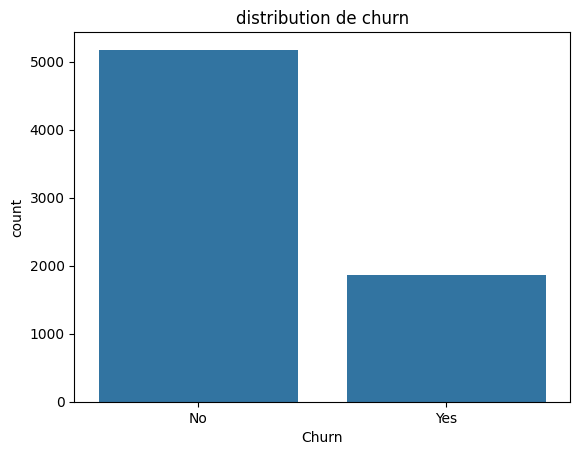

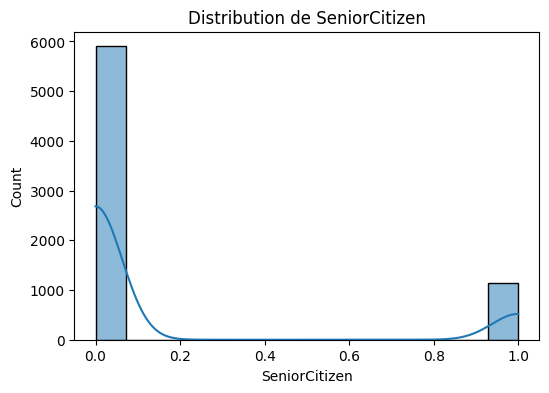

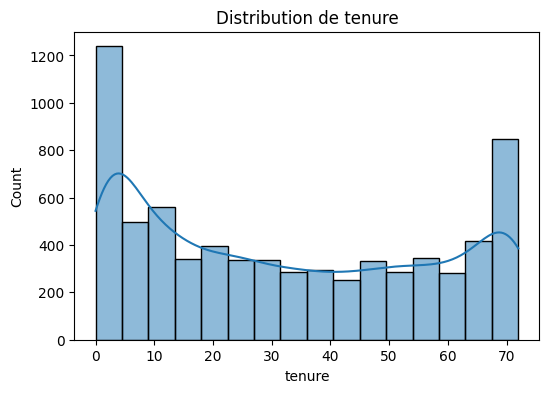

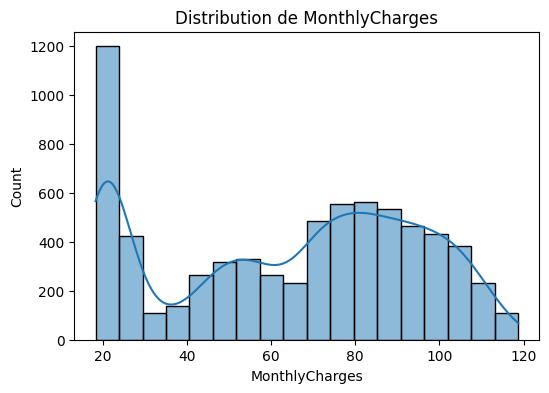

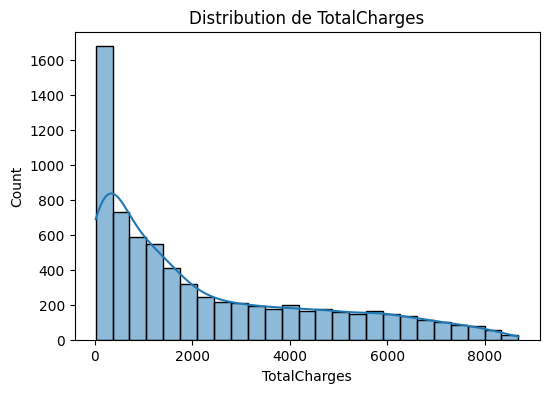

In [12]:

# #****************** MATPLOTLIB ET SEABORN (distribution des columns numeriques)******************************
#distribution de churn
sns.countplot(data=df, x="Churn")
plt.title("distribution de churn")
plt.show()
for col in colonnes_numeriques:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()


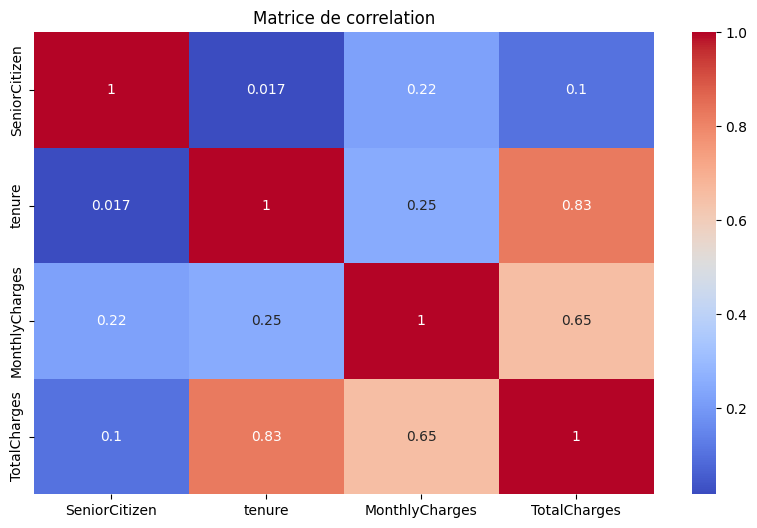

In [13]:

# #*********************correlation**************************
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de correlation")
plt.show()

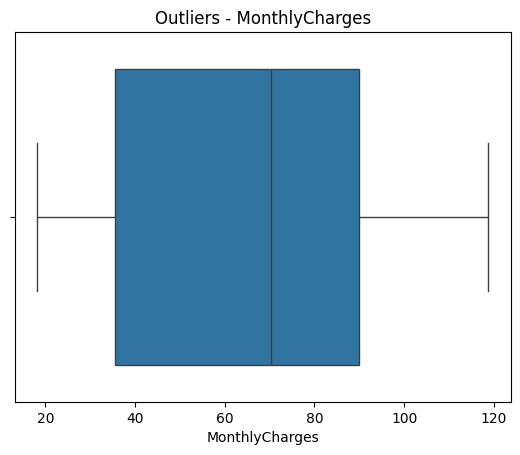

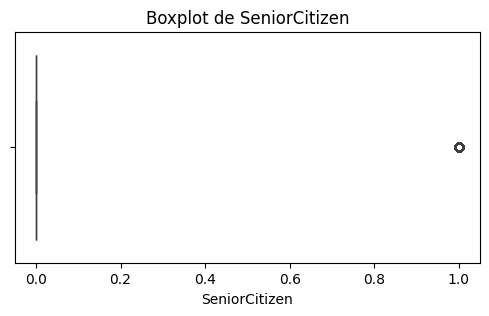

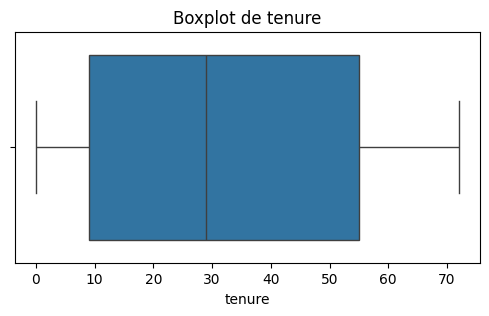

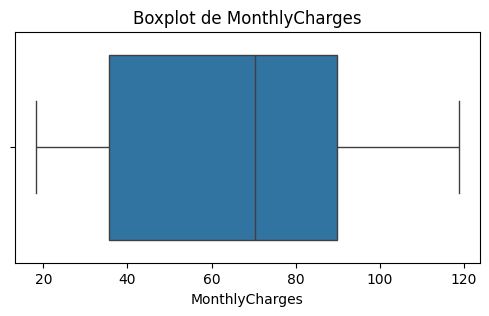

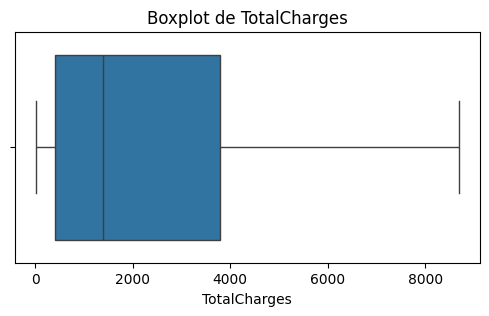

Nombre d'outliers : 0


In [14]:

#***********Outliers************
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Outliers - MonthlyCharges")
plt.show()

# # detecter outliers
for col in colonnes_numeriques:

    plt.figure(figsize=(6, 3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot de {col}")

    plt.show()
    
#avec IQR
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalCharges"] < lower_bound) |
    (df["TotalCharges"] > upper_bound)
]

print("Nombre d'outliers :", len(outliers))


In [15]:

#*************Feature engineering************
#moyen de total charges (avec non (total/0==total/1))
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, 1)
)


import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

print("Fichier cleaned_data.csv créé avec succès !")


Fichier cleaned_data.csv créé avec succès !


In [16]:
#Encoding + Standardisation
# ****************** PREPARATION DES VARIABLES ******************************

X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Variables numériques :")
print(numeric_features)

print("Variables catégorielles :")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



Shape de X : (7043, 21)
Shape de y : (7043,)
Variables numériques :
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlySpend'],
      dtype='object')
Variables catégorielles :
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
